In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os, sys
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import geopandas as gpd
import shapely
import pandas as pd
from geodatasets import get_path
import ast
# import geopy.distances
from tqdm import tqdm

import matplotlib as mpl
from matplotlib.colors import ListedColormap
sys.path.append('../src/')
sys.path.append('../content/')
import data_utils as du
import gee_utils as gu
import vis_utils as vu
import sample_locations as sl
import loadpaths
path_dict_pecl = loadpaths.loadpaths()
# import shapely
# from tqdm import tqdm, tqdm_notebook
# import ast, shutil

In [3]:
import ee, geemap
import api_keys

ee.Authenticate()
ee.Initialize(project=api_keys.GEE_API)
geemap.ee_initialize()

## Load all downloaded locations (with DW LC)

In [6]:
countries = gpd.read_file('/Users/tplas/data/ne_110m_admin_0_countries/ne_110m_admin_0_countries.shp')


In [ ]:
folder_locations = '/Users/tplas/data/dw_sampled_locations/spherical'
n_points_max = 100000
assert os.path.exists(folder_locations), f"Folder {folder_locations} does not exist. Please run the sample function to create it."
df_points = None
for ii, f in enumerate(os.listdir(folder_locations)):
    if f.endswith('.csv'):
        print(f"Reading {f}...")
        if df_points is None:
            df_points = pd.read_csv(os.path.join(folder_locations, f))
        else:
            df_points = pd.concat([df_points, pd.read_csv(os.path.join(folder_locations, f))], ignore_index=True)
df_points = df_points[df_points.lat > -56.0]  # limit to latitudes > -56 deg S
df_points = df_points[:n_points_max]
df_points = df_points.reset_index(drop=True)
gdf_points = gpd.GeoDataFrame(df_points, geometry=gpd.points_from_xy(df_points.lon, df_points.lat), crs='EPSG:4326')
assert gdf_points.geometry.nunique() == len(gdf_points), f'{len(gdf_points) - gdf_points.geometry.nunique()} duplicate points found!'

print(f"Total number of unique points: {len(gdf_points)}")

Reading dw_locations_2026-02-11-1832_year-2024_3791-samples_50m_spherical.csv...
Reading dw_locations_2026-02-11-1835_year-2024_3767-samples_50m_spherical.csv...
Reading dw_locations_2026-02-11-1837_year-2024_3740-samples_50m_spherical.csv...
Reading dw_locations_2026-02-12-1725_year-2024_50m_spherical_v0.csv...
Reading dw_locations_2026-02-12-2050_year-2024_50m_spherical_v0.csv...
Reading dw_locations_2026-02-12-2050_year-2024_50m_spherical_v1.csv...
Reading dw_locations_2026-02-11-1836_year-2024_3754-samples_50m_spherical.csv...
Reading dw_locations_2026-02-11-1832_year-2024_3755-samples_50m_spherical.csv...
Reading dw_locations_2026-02-12-1804_year-2024_50m_spherical_v1.csv...
Reading dw_locations_2026-02-12-1804_year-2024_50m_spherical_v0.csv...
Reading dw_locations_2026-02-12-1804_year-2024_50m_spherical_v2.csv...
Reading dw_locations_2026-02-11-1836_year-2024_3773-samples_50m_spherical.csv...
Reading dw_locations_2026-02-12-1804_year-2024_50m_spherical_v3.csv...
Reading dw_locati

Text(0.5, 1.0, '100000 sampled Dynamic World locations (trees)')

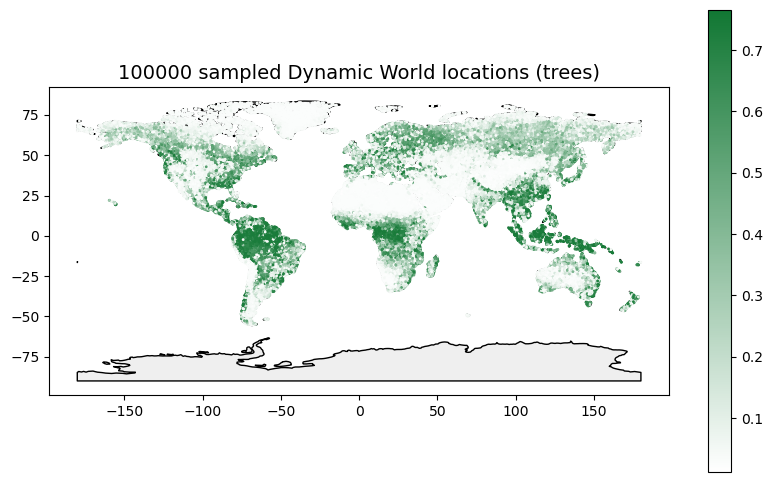

In [10]:
col_plot = 'trees'  # 'label' or any of the individual classes

fig, ax = plt.subplots(figsize=(10, 6))
cmap_dict = du.create_mpl_cmap_dynamic_world()
countries.plot(ax=ax, color="#EFEFEF", edgecolor='black')
gdf_points.plot(ax=ax, column=col_plot, markersize=1, 
                cmap=cmap_dict['all'] if col_plot == 'label' else cmap_dict['individual'][col_plot], 
                legend=False if col_plot == 'label' else True)

if col_plot == 'label':
    dw_classes = du.DW_CLASSES
    norm = mpl.colors.BoundaryNorm(
        boundaries=range(len(dw_classes) + 1),
        ncolors=len(dw_classes)
    )

    sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap_dict['all'])
    sm.set_array([])

    cbar = fig.colorbar(
        sm,
        ax=ax,
        ticks=range(len(dw_classes)),
        shrink=0.67,
        pad=0.02
    )

    cbar.set_ticks(np.arange(len(dw_classes)) + 0.5)
    cbar.set_ticklabels(dw_classes)
    cbar.set_label("DW land cover class", fontsize=12)

ax.set_title(f'{len(gdf_points)} sampled Dynamic World locations ({col_plot})', fontsize=14)
# ax.set_xlim(-10, 10)
# ax.set_ylim(45, 60)



/var/folders/kh/y9z_055x6gq8gc74b6y16r1c0000gn/T/ipykernel_22697/1176917614.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(sl.DW_CLASSES, rotation=45, ha='right')
/var/folders/kh/y9z_055x6gq8gc74b6y16r1c0000gn/T/ipykernel_22697/1176917614.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(sl.DW_CLASSES, rotation=45, ha='right')
/var/folders/kh/y9z_055x6gq8gc74b6y16r1c0000gn/T/ipykernel_22697/1176917614.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[2].set_xticklabels(sl.DW_CLASSES, rotation=45, ha='right')


Text(0, 0.5, 'Number of samples')

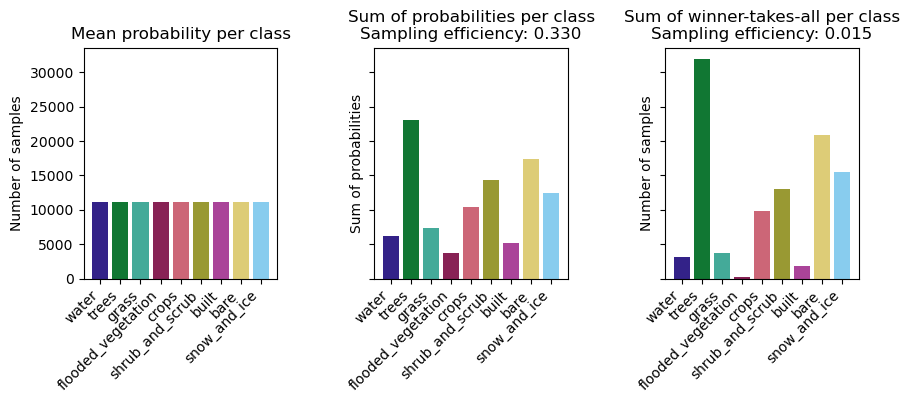

In [11]:
fig, ax = plt.subplots(1, 3, figsize=(10, 3), gridspec_kw={'wspace': 0.5}, sharey=True)
# for dw in sl.DW_CLASSES:
#     distr = gdf_points[dw].values
#     ax[0].hist(distr, bins=100, alpha=0.8, label=dw, color=du.create_cmap_dynamic_world()[dw], histtype='step')
# ax[0].set_yscale('log')
# ax[0].set_title('Distribution of probabilities\nper class')
# ax[0].set_xlabel('Probability')
# ax[0].set_ylabel('Count (log scale)')
mean = np.mean(gdf_points[sl.DW_CLASSES].values) * len(gdf_points)
ax[0].bar(sl.DW_CLASSES, mean, color=[du.create_cmap_dynamic_world()[dw] for dw in sl.DW_CLASSES])
ax[0].set_xticklabels(sl.DW_CLASSES, rotation=45, ha='right')
ax[0].set_title('Mean probability per class')
ax[0].set_ylabel('Number of samples')

sum_dw_probs = gdf_points[sl.DW_CLASSES].sum()
c_eff_probs = np.min(sum_dw_probs) / np.mean(sum_dw_probs)
ax[1].bar(sl.DW_CLASSES, sum_dw_probs, color=[du.create_cmap_dynamic_world()[dw] for dw in sl.DW_CLASSES])
ax[1].set_xticklabels(sl.DW_CLASSES, rotation=45, ha='right')
ax[1].set_title(f'Sum of probabilities per class\nSampling efficiency: {c_eff_probs:.3f}')
ax[1].set_ylabel('Sum of probabilities')

sum_dw_labels = [np.sum(gdf_points['label'] == i_dw) for i_dw, dw in enumerate(sl.DW_CLASSES)]
c_eff_labels = np.min(sum_dw_labels) / np.mean(sum_dw_labels)
ax[2].bar(sl.DW_CLASSES, sum_dw_labels, color=[du.create_cmap_dynamic_world()[dw] for dw in sl.DW_CLASSES])
ax[2].set_xticklabels(sl.DW_CLASSES, rotation=45, ha='right')
ax[2].set_title(f'Sum of winner-takes-all per class\nSampling efficiency: {c_eff_labels:.3f}')
ax[2].set_ylabel('Number of samples')

## Get a sample from the full dataset:

### Get single sample:

In [12]:
sample_strategy = 'flooded_vegetation'  # 'greedy', 'random', 'entropy', or any of the individual classes
size_sample = 10000
target_distr = np.array([1 / len(sl.DW_CLASSES)] * len(sl.DW_CLASSES))
if sample_strategy == 'greedy':
    sample_inds_best, c_eff, entropy = sl.sample_evenly_from_biased_distr(gdf_points=gdf_points, size_sample=size_sample, 
                                                                 ratio_start=0.15, ratio_prune=0.0, step_size=5)
    print(f'Greedy sampling: C_eff = {c_eff:.3f}, H = {entropy:.2f}, I = {np.exp(entropy):.2f}')
elif sample_strategy == 'random':

    max_it = 20000
    it = 0
    best = np.inf
    sample_inds_best = None
    while it < max_it:
        inds_sample = np.random.choice(len(gdf_points), size_sample, replace=False)
        sample = gdf_points.iloc[inds_sample]
        sum_sample = sample[sl.DW_CLASSES].sum()
        distr_sample = sum_sample / size_sample
        dist = np.linalg.norm(distr_sample - target_distr, ord=2)
        if dist < best:
            print(f"New best found at iteration {it}: distance {dist:.4f} (previous best: {best:.4f})")
            best = dist
            sample_inds_best = inds_sample
        it += 1

elif sample_strategy == 'entropy':
    entropy = - np.sum(target_distr * np.log(target_distr))
    entropy_points = - np.sum(gdf_points[sl.DW_CLASSES].values * np.log(gdf_points[sl.DW_CLASSES].values + 1e-10), axis=1)
    sample_inds_best = np.argsort(entropy_points)[-size_sample:]

elif sample_strategy in sl.DW_CLASSES:
    sample_inds_best = gdf_points.sort_values(sample_strategy, ascending=False).index[:size_sample]

### Optimise greedy sampler:

In [ ]:

best_eff = -np.inf
size_sample = 10000
list_ratio_start = np.linspace(0, 0.5, num=11)[1:]
# list_ratio_prune = np.linspace(0, 0.2, num=5)
ratio_prune = 0  # empirically found that pruning does not improve.
list_step_size = [5, 10, 20, 30, 50]
step_size = 20
results = {x: [] for x in ['ratio_start', 'ratio_prune', 'step_size', 'c_eff', 'entropy']}
sample_inds_best = None
for ratio_start in list_ratio_start:
    # for ratio_prune in list_ratio_prune:
    for step_size in list_step_size:
        tmp, c_eff, entropy = sl.sample_evenly_from_biased_distr(gdf_points=gdf_points, size_sample=size_sample, 
                                                                            ratio_start=ratio_start, ratio_prune=ratio_prune, step_size=step_size)
        results['ratio_start'].append(ratio_start)
        results['ratio_prune'].append(ratio_prune)
        results['step_size'].append(step_size)
        results['c_eff'].append(c_eff)
        results['entropy'].append(entropy)
        if c_eff > best_eff:
            print(f"New best found: C_eff {c_eff:.4f} (previous best: {best_eff:.4f}) with ratio_start={ratio_start:.2f}, ratio_prune={ratio_prune:.2f}, step_size={step_size}")
            best_eff = c_eff
            sample_inds_best = tmp



New best found: C_eff 0.6023 (previous best: -inf) with ratio_start=0.05, ratio_prune=0.00, step_size=5
New best found: C_eff 0.6060 (previous best: 0.6023) with ratio_start=0.10, ratio_prune=0.00, step_size=5
New best found: C_eff 0.6062 (previous best: 0.6060) with ratio_start=0.15, ratio_prune=0.00, step_size=5


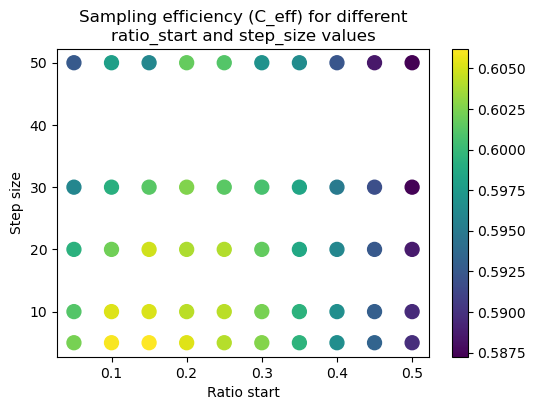

In [35]:
fig, ax = plt.subplots(figsize=(6, 4))
sc = ax.scatter(results['ratio_start'], results['step_size'], c=results['c_eff'], cmap='viridis', s=100)
ax.set_xlabel('Ratio start')
ax.set_ylabel('Step size')
ax.set_title('Sampling efficiency (C_eff) for different\nratio_start and step_size values')
cbar = plt.colorbar(sc, ax=ax)

### Plot results:

/Users/tplas/repos/interpret_earth_embeddings/notebooks/../src/sample_locations.py:151: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_distr.set_xticklabels(DW_CLASSES, rotation=45, ha='right')
/Users/tplas/repos/interpret_earth_embeddings/notebooks/../src/sample_locations.py:151: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_distr.set_xticklabels(DW_CLASSES, rotation=45, ha='right')
/Users/tplas/repos/interpret_earth_embeddings/notebooks/../src/sample_locations.py:151: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_distr.set_xticklabels(DW_CLASSES, rotation=45, ha='right')


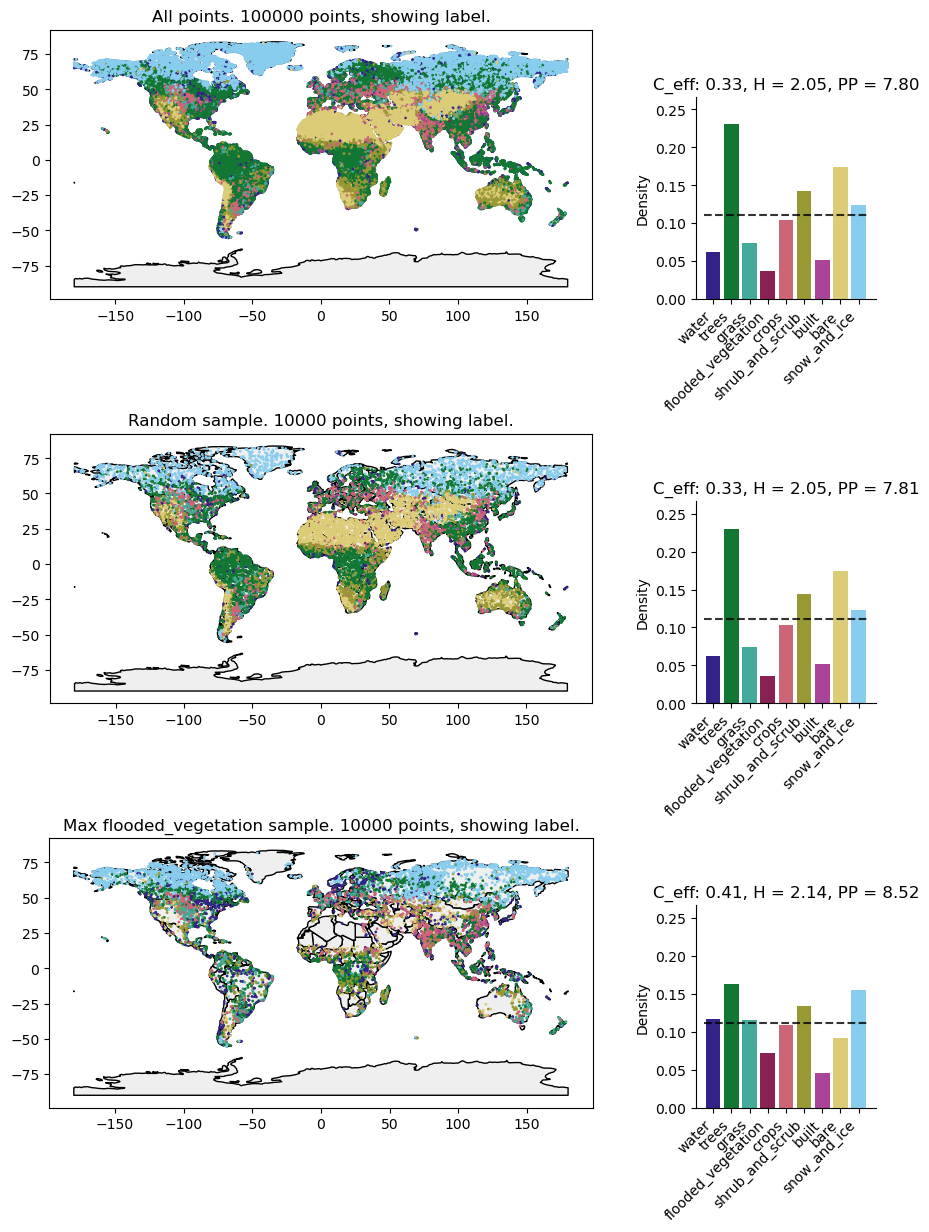

In [14]:
fig = plt.figure(figsize=(12, 14))
gs_map = plt.GridSpec(3, 1, hspace=0.5, right=0.75)
gs_distr = plt.GridSpec(3, 1, hspace=0.5, left=0.75)
ax_map = [fig.add_subplot(gs_map[i]) for i in range(3)]
ax_distr = [fig.add_subplot(gs_distr[i]) for i in range(3)]

sl.plot_map_and_distr(gdf=gdf_points, countries=countries, ax_map=ax_map[0], ax_distr=ax_distr[0], name='All points.')

inds_random = np.random.choice(len(gdf_points), size=size_sample, replace=False)
sl.plot_map_and_distr(gdf=gdf_points.iloc[inds_random], countries=countries, ax_map=ax_map[1], ax_distr=ax_distr[1], name='Random sample.')

sl.plot_map_and_distr(gdf=gdf_points.iloc[sample_inds_best], countries=countries, ax_map=ax_map[2], ax_distr=ax_distr[2], name='Max flooded_vegetation sample.')

ymax = 0
for ax_ in ax_distr:
    ymax = max(ymax, ax_.get_ylim()[1])
for ax_ in ax_distr:
    ax_.set_ylim(0, ymax * 1.1)
    box = ax_.get_position()
    ax_.set_position([box.x0, box.y0, box.width, box.height * 0.75])

In [16]:
gdf_points.iloc[sample_inds_best].lc_stratified_sample.sum()

np.int64(7038)

In [ ]:
save = False
## create df with random inds and best inds
gdf_final = gdf_points.copy()
gdf_final['random_sample'] = 0
gdf_final.loc[inds_random, 'random_sample'] = 1
gdf_final['lc_stratified_sample'] = 0
gdf_final.loc[sample_inds_best, 'lc_stratified_sample'] = 1
gdf_final['id'] = gdf_final.index
gdf_final = gdf_final[['id', 'lat', 'lon', 'geometry', 'random_sample', 'lc_stratified_sample', 'label'] + sl.DW_CLASSES]
if save:
    gdf_final.to_csv('/Users/tplas/data/dw_sampled_locations/dw_locations_2026-02-13-1659_year-2024_50m_spherical_100k_random_stratified.csv', index=False)

In [8]:
gdf_points = pd.read_csv('/Users/tplas/data/dw_sampled_locations/dw_locations_2026-02-13-1659_year-2024_50m_spherical_100k_random_stratified.csv')
# tmp[np.logical_or(tmp['random_sample'] == 1, tmp['lc_stratified_sample'] == 1)].id
# tmp['id'] = tmp.index
# print(tmp.columns, len(tmp.columns))
# tmp = tmp[['id', 'lat', 'lon', 'geometry', 'random_sample', 'lc_stratified_sample', 'label'] + sl.DW_CLASSES]
# print(tmp.columns, len(tmp.columns))
# tmp.to_csv('/Users/tplas/data/dw_sampled_locations/dw_locations_2026-02-13-1659_year-2024_50m_spherical_100k_random_stratified.csv', index=False)
gdf_points = gpd.GeoDataFrame(gdf_points, geometry=gpd.points_from_xy(gdf_points.lon, gdf_points.lat), crs='EPSG:4326')

In [119]:
content = set([int(x.split('_')[0]) if not x.startswith('.') else None for x in os.listdir('/Users/tplas/data/dw_sampled_locations/data_spherical') if not x.startswith('.')])
for id in tmp[np.logical_or(tmp['random_sample'] == 1, tmp['lc_stratified_sample'] == 1)].id:
    if id not in content:
        print(f"ID {id} is missing from the data folder!")
print(len(content), len(tmp[np.logical_or(tmp['random_sample'] == 1, tmp['lc_stratified_sample'] == 1)]))

18973 18973


In [102]:
tmp

<xarray.DataArray (band: 4, y: 128, x: 128)> Size: 262kB
array([[[4272, 4268, 4244, ..., 4288, 4284, 4284],
        [4272, 4228, 4228, ..., 4260, 4296, 4284],
        [4272, 4252, 4244, ..., 4300, 4284, 4256],
        ...,
        [4220, 4232, 4264, ..., 4320, 4328, 4308],
        [4240, 4220, 4240, ..., 4352, 4284, 4272],
        [4188, 4212, 4240, ..., 4320, 4320, 4300]],

       [[2938, 2916, 2874, ..., 2878, 2858, 2898],
        [2938, 2888, 2876, ..., 2878, 2896, 2918],
        [2900, 2884, 2906, ..., 2872, 2878, 2858],
        ...,
        [2864, 2852, 2884, ..., 2912, 2890, 2890],
        [2856, 2840, 2884, ..., 2912, 2880, 2934],
        [2880, 2862, 2884, ..., 2906, 2912, 2924]],

       [[1832, 1762, 1832, ..., 1772, 1810, 1828],
        [1836, 1844, 1812, ..., 1766, 1766, 1784],
        [1764, 1786, 1764, ..., 1746, 1724, 1772],
        ...,
        [1760, 1760, 1742, ..., 1804, 1786, 1776],
        [1794, 1804, 1766, ..., 1844, 1800, 1810],
        [1778, 1760, 1746, ..., 1776, 1780, 1826]],

       [[4984, 4996, 5020, ..., 5004, 5048, 5048],
        [4960, 4980, 4980, ..., 5020, 5048, 4992],
        [4960, 5004, 4968, ..., 5004, 5004, 5024],
        ...,
        [5040, 5004, 4996, ..., 5068, 5048, 5080],
        [4984, 5040, 5016, ..., 5068, 5048, 5080],
        [4892, 4984, 5016, ..., 5080, 5064, 5040]]],
      shape=(4, 128, 128), dtype=int32)
Coordinates:
  * band         (band) int64 32B 1 2 3 4
  * x            (x) float64 1kB 2.781e+05 2.781e+05 ... 2.793e+05 2.794e+05
  * y            (y) float64 1kB 2.635e+06 2.635e+06 ... 2.634e+06 2.634e+06
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:           Area
    TIFFTAG_RESOLUTIONUNIT:  1 (unitless)
    TIFFTAG_XRESOLUTION:     1
    TIFFTAG_YRESOLUTION:     1
    _FillValue:              0.0
    scale_factor:            1.0
    add_offset:              0.0

<Axes: >

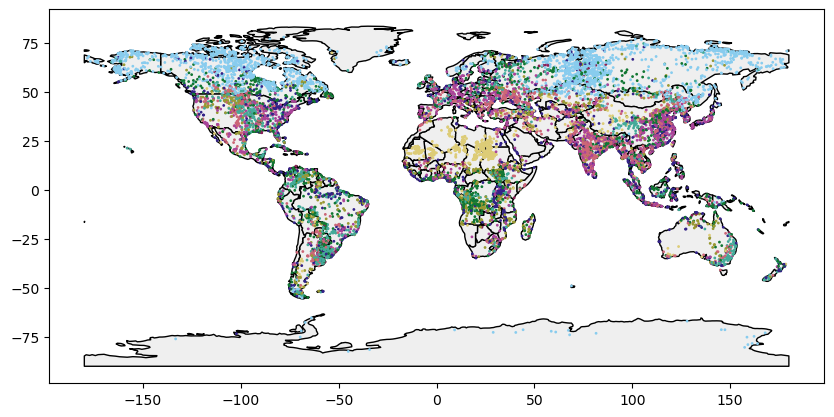

In [30]:
fig, ax = plt.subplots(figsize=(10, 6))
cmap_dict = du.create_mpl_cmap_dynamic_world()
col_plot = 'label'
countries.plot(ax=ax, color="#EFEFEF", edgecolor='black')
gdf_points.iloc[sample_inds_best].plot(ax=ax, column=col_plot, markersize=1, 
                cmap=cmap_dict['all'] if col_plot == 'label' else cmap_dict['individual'][col_plot], 
                legend=False if col_plot == 'label' else True)


(9,)


/var/folders/kh/y9z_055x6gq8gc74b6y16r1c0000gn/T/ipykernel_1533/890860031.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(sl.DW_CLASSES, rotation=45, ha='right')
/var/folders/kh/y9z_055x6gq8gc74b6y16r1c0000gn/T/ipykernel_1533/890860031.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(sl.DW_CLASSES, rotation=45, ha='right')
/var/folders/kh/y9z_055x6gq8gc74b6y16r1c0000gn/T/ipykernel_1533/890860031.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[2].set_xticklabels(sl.DW_CLASSES, rotation=45, ha='right')


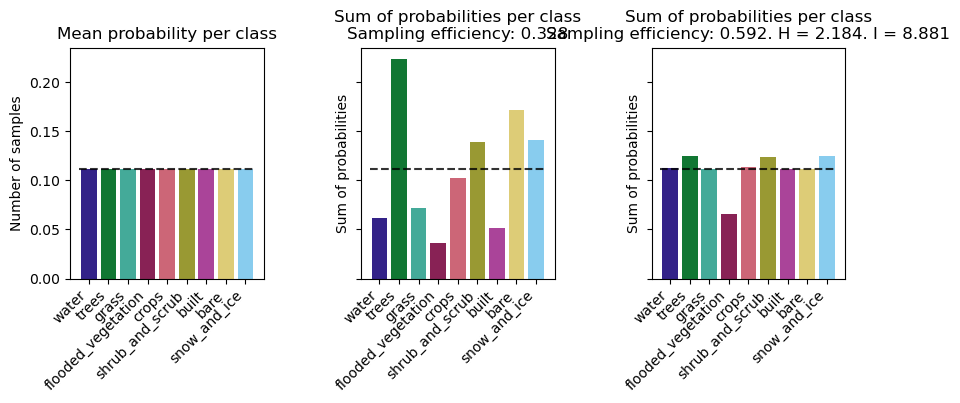

In [61]:
sample_inds_best, c_eff, entropy = sl.sample_evenly_from_biased_distr(gdf_points=gdf_points, size_sample=10000, ratio_start=0.2, ratio_prune=0.1, step_size=20)

fig, ax = plt.subplots(1, 3, figsize=(10, 3), gridspec_kw={'wspace': 0.5}, sharey=True)
mean = np.mean(gdf_points[sl.DW_CLASSES].values)

ax[0].bar(sl.DW_CLASSES, mean, color=[du.create_cmap_dynamic_world()[dw] for dw in sl.DW_CLASSES])
ax[0].set_xticklabels(sl.DW_CLASSES, rotation=45, ha='right')
ax[0].set_title('Mean probability per class')
ax[0].set_ylabel('Number of samples')

sum_dw_probs = gdf_points[sl.DW_CLASSES].sum() / len(gdf_points)
c_eff_probs = np.min(sum_dw_probs) / np.mean(sum_dw_probs)
ax[1].bar(sl.DW_CLASSES, sum_dw_probs, color=[du.create_cmap_dynamic_world()[dw] for dw in sl.DW_CLASSES])
ax[1].set_xticklabels(sl.DW_CLASSES, rotation=45, ha='right')
ax[1].set_title(f'Sum of probabilities per class\nSampling efficiency: {c_eff_probs:.3f}')
ax[1].set_ylabel('Sum of probabilities')

sum_dw_probs_sample = gdf_points[sl.DW_CLASSES].iloc[sample_inds_best].sum() / len(sample_inds_best)
c_eff_probs_sample = np.min(sum_dw_probs_sample) / np.mean(sum_dw_probs_sample)
ax[2].bar(sl.DW_CLASSES, sum_dw_probs_sample, color=[du.create_cmap_dynamic_world()[dw] for dw in sl.DW_CLASSES])
ax[2].set_xticklabels(sl.DW_CLASSES, rotation=45, ha='right')
ax[2].set_title(f'Sum of probabilities per class\nC_eff: {c_eff_probs_sample:.2f}. H = {entropy:.2f}. I = {np.exp(entropy):.2f}')
ax[2].set_ylabel('Sum of probabilities')

for ax_ in ax:
    ax_.plot([-0.5, len(sl.DW_CLASSES) - 0.5], [1 / len(sl.DW_CLASSES)] * 2, 'k--', alpha=0.8)

## Verify downloaded data

In [99]:
# len(gdf_points[np.logical_or(gdf_points['random_sample'] == 1, gdf_points['lc_stratified_sample'] == 1)])
gdf_points = pd.read_csv('/Users/tplas/data/dw_locations_2026-02-13-1659_year-2024_50m_spherical_100k_random_stratified.csv'
                    )
len(gdf_points[np.logical_or(gdf_points['random_sample'] == 1, gdf_points['lc_stratified'] == 1)])


18973

In [ ]:
folder = '/Users/tplas/data/dw_sampled_locations/data_spherical/'
content = [x for x in os.listdir(folder) if (not x.endswith('.json') and x != '.DS_Store')]
# content

id_list = []
modality_list = []
for f in content:
    id = int(f.split('_')[0])
    modality = f.split('_')[1]
    id_list.append(id)
    modality_list.append(modality)

df_content = pd.DataFrame({'id': id_list, 'modality': modality_list})
df_content = df_content.sort_values('id')
print(df_content.value_counts('modality'))
df_content[np.logical_or(df)]

modality
alphaearth      18969
dynamicworld    18969
dsm             18401
Name: count, dtype: int64
{85529: 2, 99226: 2, 67578: 2, 50606: 2, 91430: 2, 61727: 2, 61995: 2, 47493: 2, 14382: 2, 99347: 2, 31213: 2, 86343: 2, 60914: 2, 66476: 2, 47518: 2, 73524: 2, 56059: 2, 92187: 2, 67485: 2, 1737: 2, 67070: 2, 37480: 2, 48938: 2, 25750: 2, 93280: 2, 42074: 2, 50659: 2, 99202: 2, 61958: 2, 73272: 2, 13786: 2, 62681: 2, 26138: 2, 48476: 2, 48354: 2, 98868: 2, 31758: 2, 56046: 2, 25027: 2, 6517: 2, 11927: 2, 14346: 2, 72204: 2, 91449: 2, 81481: 2, 48858: 2, 73795: 2, 17961: 2, 40821: 2, 56154: 2, 72184: 2, 32102: 2, 32130: 2, 13153: 2, 41159: 2, 36303: 2, 74554: 2, 41598: 2, 17952: 2, 92708: 2, 18852: 2, 57493: 2, 87549: 2, 72018: 2, 32147: 2, 47347: 2, 12660: 2, 87553: 2, 73593: 2, 56562: 2, 66819: 2, 49048: 2, 99981: 2, 35624: 2, 84855: 2, 30903: 2, 72820: 2, 13665: 2, 87574: 2, 74541: 2, 81575: 2, 84906: 2, 63368: 2, 13285: 2, 6446: 2, 26263: 2, 81556: 2, 57469: 2, 48947: 2, 1785: 2, 57

In [177]:
sum_dw_probs_sample

water                 0.118193
trees                 0.161945
grass                 0.101182
flooded_vegetation    0.051175
crops                 0.110210
shrub_and_scrub       0.127802
built                 0.063938
bare                  0.105070
snow_and_ice          0.160446
dtype: float64

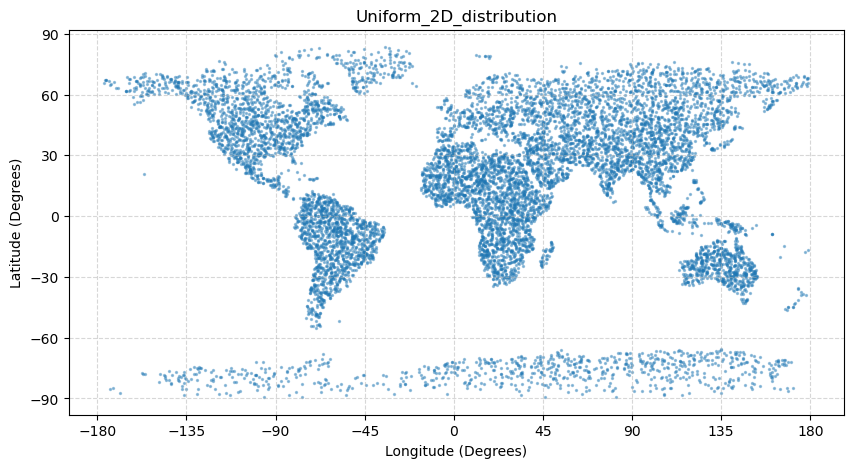

In [102]:
plot_2d_distribution(np.array([[p.x, p.y] for p in points]), "Uniform_2D_distribution")

## 3D sampling

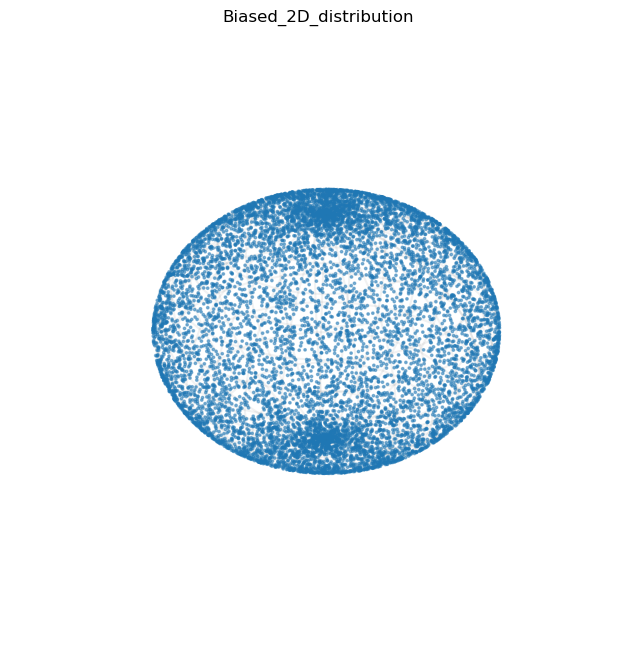

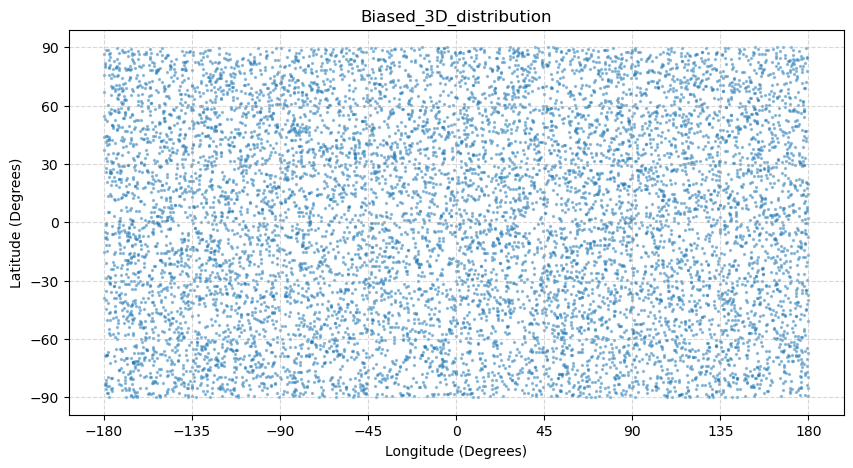

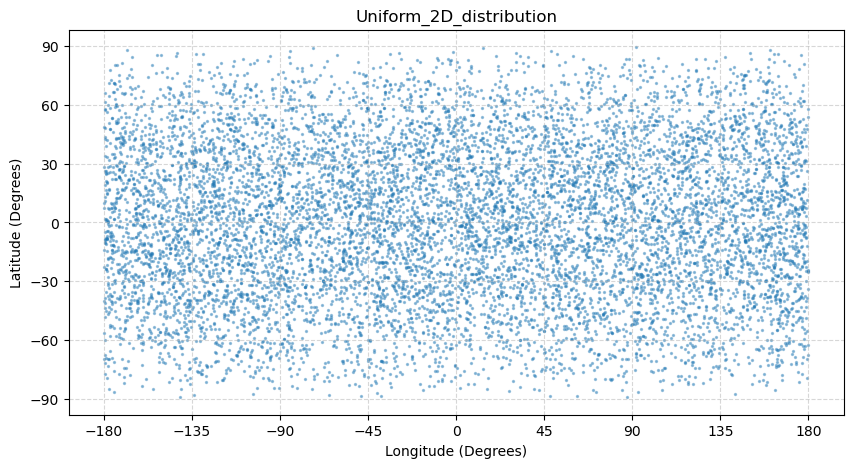

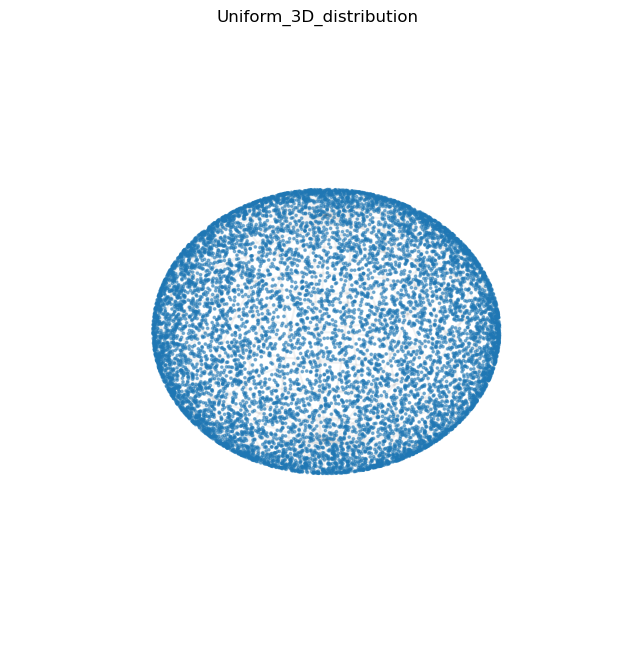

In [85]:

def plot_2d_distribution(coords, title):
    
    lon, lat = coords[:, 0], coords[:, 1]

    fig, ax = plt.subplots(figsize=(10, 5))
    scatter = ax.scatter(lon, lat, s=2, alpha=0.4)

    ax.set_xlabel("Longitude (Degrees)")
    ax.set_ylabel("Latitude (Degrees)")
    ax.set_title(title)
    ax.set_xticks(np.arange(-180, 181, 45))
    ax.set_yticks(np.arange(-90, 91, 30))
    ax.grid(True, linestyle='--', alpha=0.5)

    plt.savefig(title + ".png")


def plot_3d_distribution(coords, title):
    lon_rad = np.radians(coords[:, 0])
    lat_rad = np.radians(coords[:, 1])

    # Convert Spherical to Cartesian
    x = np.cos(lat_rad) * np.cos(lon_rad)
    y = np.cos(lat_rad) * np.sin(lon_rad)
    z = np.sin(lat_rad)

    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, projection='3d')

    # Plot the points
    ax.scatter(x, y, z, s=3, alpha=0.5)

    # Aesthetics: Draw a wireframe sphere
    u, v = np.mgrid[0:2 * np.pi:30j, 0:np.pi:15j]
    sx, sy, sz = np.cos(u) * np.sin(v), np.sin(u) * np.sin(v), np.cos(v)
    ax.plot_wireframe(sx, sy, sz, color="black", alpha=0.05)

    ax.set_title(title)
    ax.set_axis_off()
    plt.savefig(title + ".png")

# Bad example
n = 10000
lat = np.random.uniform(-90, 90, n)
lon = np.random.uniform(-180, 180, n)

points = np.stack([lon, lat], axis=1)
plot_3d_distribution(points, "Biased_2D_distribution")
plot_2d_distribution(points, 'Biased_3D_distribution')

# Good example: Corrected Uniform Sampling
n = 10000

# 1. Longitude is still uniform from -180 to 180
lon = np.random.uniform(-180, 180, n)

# 2. Latitude requires an inverse sine transformation to avoid pole-clumping
u = np.random.uniform(-1, 1, n)
lat_good = np.degrees(np.arcsin(u))

points_good = np.stack([lon, lat_good], axis=1)

# Visualize the corrected distribution
plot_2d_distribution(points_good, "Uniform_2D_distribution")
plot_3d_distribution(points_good, "Uniform_3D_distribution")

## Stratified sample via online GEE LC dataset
Works, but requires heavy GEE computation -> memory/budget constraints.

In [ ]:
prob_bands = [
    "water", "trees", "grass", "flooded_vegetation",
    "crops", "shrub_and_scrub", "built", "bare", "snow_and_ice"
]
label_band = 'label'
ex_collection = ee.ImageCollection("GOOGLE/DYNAMICWORLD/V1")
coords = (51, 4)
point = ee.Geometry.Point(coords)
aoi = point.buffer(2000).bounds()
assert ex_collection is not None

year = 2019
epsg_code = 32631  # UTM zone 31N
im_gee = ee.Image(ex_collection
                            .filterDate(ee.Date(f'{year}-01-01'), ee.Date(f'{year}-12-31'))
                            .select(label_band)  # get all probability bands
                            .mean()
)

points = im_gee.stratifiedSample(numPoints=5000,
                                 classBand=label_band,
                                 scale=10,
                                 projection=f'EPSG:{epsg_code}',
                                 seed=0,
                                 dropNulls=True,
                                 geometries=True,
                                 )

In [ ]:
def stratified_sample_dw_points(year=2024, centre_coords=(51.733075, -1.307027)[::-1], 
                                buffer_m=10000, num_points=5, scale=100, seed=0):

    # coords = (51.733075, -1.307027)[::-1]
    # coords = (46.675396, 6.931036)[::-1]  # Switzerland
    epsg_code = 32632  # UTM zone 32N
    point = ee.Geometry.Point(centre_coords)
    aoi = point.buffer(buffer_m).bounds()

    prob_bands = [
        "water", "trees", "grass", "flooded_vegetation",
        "crops", "shrub_and_scrub", "built", "bare", "snow_and_ice"
    ]

    dw_probs = (ee.ImageCollection("GOOGLE/DYNAMICWORLD/V1")
                .filterBounds(aoi)
                .filterDate(f"{year}-01-01", f"{year}-12-31")
                .select(prob_bands)
                .mean() 
                .reproject(f'EPSG:{epsg_code}', scale=scale)  # reproject to 10m
                .clip(aoi)
                )

    # Get valid projection from any prob band
    proj = dw_probs.select(0).projection()

    label_img = (
        dw_probs
        .toArray()
        .arrayArgmax()
        .arrayProject([0])
        .arrayFlatten([['label']])
        .toInt()
        .reproject(proj)
    )


    points = label_img.stratifiedSample(
        numPoints = num_points,
        classBand = "label",
        scale = scale,
        seed = seed,
        dropNulls = True,
        geometries = True
    )

    coord_list = []
    label_list = []

    for feature in points.getInfo()['features']:
        coords = feature['geometry']['coordinates']
        label = feature['properties']['label']
        coord_list.append((coords[0], coords[1]))
        label_list.append(label)

    gdf_samples = gpd.GeoDataFrame({'label': label_list}, 
                                   geometry=gpd.points_from_xy([c[0] for c in coord_list], [c[1] for c in coord_list]))
    gdf_samples.crs = f'EPSG:{epsg_code}'
    return gdf_samples, points

# %timeit gdf_samples, points = stratified_sample_dw_points()